# Análisis exploratorio: fraude en verificación de identidad

**Objetivo:** entender los datos antes de modelar: qué representa cada fila, qué columnas son confiables, dónde hay señal y qué riesgos de fuga existen.

**Datos:** `data_anonymized.csv`: 17.781 procesos de verificación, 59 columnas, nov 2023 – ago 2024.

**Resumen de hallazgos**
1. **Dos fuentes con esquemas distintos** (§5): cada cliente nombra distinto las mismas señales; se unifican.
2. **Distribución temporal sesgada** (§6): meses con 100 % de fraude y clientes que no se solapan; no se puede partir por tiempo.
3. **Etiqueta casi por cuenta** (§7): la partición debe agruparse por `ACCOUNT_ID`.
4. **Dispositivo, red y geografía son ruido sintético** (§8, §9, §9.5): AUC ≈ 0,5 solas y combinadas; se excluyen.
5. **`STATUS` y `DECLINED_REASON` son resultado del proceso** (§10): riesgo de fuga.
6. **Señal real** (§11): `DISTRUST`, antigüedad, historial de la cuenta e identidad compartida.

Las decisiones se trasladan a `config.yaml` (§12).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score

In [2]:
df = pd.read_csv('../data/raw/data_anonymized.csv', low_memory=False)
y = df['IS_FRAUD'].astype(int)

## 1. Radiografía del dataset
**Pregunta:** ¿qué forma tienen los datos y qué representa cada fila?

In [3]:
print(df.shape)
print(df.dtypes.value_counts())
df.head().T

(17781, 59)
str        31
float64    11
bool        8
int64       7
object      2
Name: count, dtype: int64


,0,1,2,3,4
PROCESS_ID,fdbab05095c0cf815c5f78b18d37b76ac0c22fbb151510...,f6e26ba1c5b301b9fa63e43dd5ddee54663f002b651cf8...,55c7a594547ea0c16ac837578e8d8350a3e4e9fe75710c...,2f88f0e87c7ed6a9b5bdddd28ecf985ab2a98d81ecdb34...,6bf342b9938b49944067827e5b0a4825a9ff6a0e9b260f...
ACCOUNT_ID,28dc4f5353db8a1733bcd4c07e7a3a28e63fb690c89f0d...,784651e9979bed36c825fe2182cd8cffd4374321ebaf69...,910f75fe1fb9df43dc8baa83d878895aebba274ae480ec...,b290f9db406ce0fc912d1a746003dbe7169094563e5ca1...,60c86da82b082cfde0ff60036266526a1cc68af63ab859...
ANOMALY,NaN,NaN,NaN,NaN,NaN
Advice,NaN,NaN,NaN,NaN,NaN
Anomaly,NaN,NaN,NaN,NaN,NaN
BROWSER_NAME,Safari,Firefox,Safari,Edge,Safari
BROWSER_VERSION,91,117,126,107,94
CITY_NAME,Resende,London,London,New York,Tokyo
CLIENT_ID,6016f351bf654d3ffc2369bb405650b62ad5ea5bc89e4b...,6016f351bf654d3ffc2369bb405650b62ad5ea5bc89e4b...,6016f351bf654d3ffc2369bb405650b62ad5ea5bc89e4b...,6016f351bf654d3ffc2369bb405650b62ad5ea5bc89e4b...,6016f351bf654d3ffc2369bb405650b62ad5ea5bc89e4b...
CONFIDENCE_SCORE,0.361351,0.173494,0.64479,0.044709,0.092049


**Observaciones (sospechas, todavía no conclusiones):**
- En la fila 0, `COUNTRY_CODE = GB` (Reino Unido), `COUNTRY_NAME = Brazil` y `CITY_NAME = Resende`: tres países distintos en la misma fila.
- `FIRST_SEEN_GLOBAL` es de 2025, pero `DATE` es de 2023: el dispositivo se habría "visto por primera vez" después de la transacción.
- Muchas columnas vacías en las mismas filas.

Algunas fechas tienen milisegundos y otras no, así que la conversión necesita `format='ISO8601'`.

In [4]:
#Hay Milisegundos en algunos valores de las fechas

df["DATE"] = pd.to_datetime(df["DATE"], utc = True, format="ISO8601")
df["DATE"].min(), df["DATE"].max()

(Timestamp('2023-11-01 13:14:56.643000+0000', tz='UTC'),
 Timestamp('2024-08-31 23:48:45.351000+0000', tz='UTC'))

## 2. Variable objetivo
**Pregunta:** ¿cuánto fraude hay?

In [5]:
print(df['IS_FRAUD'].value_counts(dropna=False))
print(df['IS_FRAUD'].value_counts(normalize=True).round(3))

IS_FRAUD
False    14636
True      3145
Name: count, dtype: int64
IS_FRAUD
False    0.823
True     0.177
Name: proportion, dtype: float64


**Conclusión:** 3.145 fraudes (17,7 %), sin nulos. El desbalance es moderado: un modelo que siempre diga "no fraude" acierta el 82 %, así que la exactitud no sirve como métrica.

Pero el 17,7 % es un promedio. Para saber si es igual en todo el dataset, primero hay que entender qué columnas son confiables, empezando por los faltantes.

## 3. Valores faltantes
**Pregunta:** ¿qué columnas tienen faltantes, y siguen algún patrón?

In [6]:
faltantes = df.isna().mean().sort_values(ascending=False).round(3)
faltantes[faltantes > 0]

ElapsedTimeDays           1.000
ElapsedTimeHours          1.000
FirstTime                 0.898
Lifetime                  0.898
ChangedInLastSevenDays    0.894
CommonBehavior            0.894
Distrust                  0.894
RequestId                 0.894
Operator                  0.894
Anomaly                   0.894
Advice                    0.894
SimCardChange             0.894
DECLINED_REASON           0.624
LIFETIME                  0.293
DOCUMENT_TYPE             0.175
DISTRUST                  0.170
PROCESS_DATE              0.170
ANOMALY                   0.170
PHONE_NUMBER              0.050
EMAIL                     0.050
DOCUMENT_NUMBER           0.038
dtype: float64

**Conclusión:** muchas columnas tienen exactamente el mismo porcentaje de faltantes (por ejemplo, 89,4 % en todas las señales del teléfono). Si faltan en el mismo porcentaje, casi seguro faltan en las mismas filas: vienen de la misma fuente.

Además hay columnas con el mismo nombre en distinta capitalización (`ANOMALY` al 17 % y `Anomaly` al 89 %). ¿Son la misma variable? Para responderlo, reviso la cardinalidad.

## 4. Cardinalidad
**Pregunta:** ¿cuántos valores distintos tiene cada columna? Esto separa identificadores, constantes, categóricas y numéricas.

In [7]:
df.nunique().sort_values()

Advice                          1
CommonBehavior                  1
ENVIRONMENT                     1
SimCardChange                   1
ElapsedTimeHours                2
INCOGNITO                       2
ElapsedTimeDays                 2
CLIENT_ID                       2
IS_FRAUD                        2
TIMEZONE_MISMATCH               2
VISITOR_FOUND                   2
VPN_RESULT                      2
STATUS                          2
PUBLIC_VPN                      2
OS_MISMATCH                     2
ChangedInLastSevenDays          2
RELAY                           2
DOCUMENT_TYPE                   3
VPN_CONFIDENCE                  3
TIMEZONE                        3
CITY_NAME                       4
BROWSER_NAME                    4
COUNTRY_CODE                    4
DEVICE                          4
COUNTRY_NAME                    4
OS                              5
OS_VERSION                      8
Operator                        8
VELOCITY_DISTINCT_IP_5M        11
VELOCITY_DISTI

**Observaciones:**
- **Constantes** (1 valor): `ENVIRONMENT`, `Advice`, `CommonBehavior`. No aportan información.
- **`CLIENT_ID` tiene solo 2 valores.** Puede ser clave.
- **Únicas por fila**: `PROCESS_ID`, `VISITOR_ID`, `URL`, `REQUEST_ID`, `IP_ADDRESS`. Son identificadores, no variables.
- **`ACCOUNT_ID`** tiene 12.206 valores: hay cuentas con varios intentos.

Siguiente pregunta: ¿las parejas de columnas con el mismo nombre se llenan en las mismas filas?

In [8]:
# Para cada pareja: ¿en cuántas filas está llena solo una, la otra o ambas?
pares = [('ANOMALY', 'Anomaly'), ('DISTRUST', 'Distrust'),
         ('LIFETIME', 'Lifetime'), ('REQUEST_ID', 'RequestId')]

for a, b in pares:
    solo_a = (df[a].notna() & df[b].isna()).sum()
    solo_b = (df[a].isna() & df[b].notna()).sum()
    ambas = (df[a].notna() & df[b].notna()).sum()
    print(f'{a:12} / {b:12}  solo {a}: {solo_a:6}  solo {b}: {solo_b:5}  ambas: {ambas}')

ANOMALY      / Anomaly       solo ANOMALY:  14765  solo Anomaly:  1878  ambas: 0
DISTRUST     / Distrust      solo DISTRUST:  14765  solo Distrust:  1878  ambas: 0
LIFETIME     / Lifetime      solo LIFETIME:  12577  solo Lifetime:  1812  ambas: 0
REQUEST_ID   / RequestId     solo REQUEST_ID:  15903  solo RequestId:     0  ambas: 1878


**Conclusión:** `ANOMALY`/`Anomaly`, `DISTRUST`/`Distrust` y `LIFETIME`/`Lifetime` **nunca** están llenas en la misma fila: son complementarias, la misma señal con dos nombres. `REQUEST_ID`/`RequestId` sí coinciden, pero tienen formatos distintos (código corto frente a UUID): son IDs diferentes.

¿Qué determina qué versión aparece en cada fila? `CLIENT_ID`, con solo 2 valores, es el candidato natural.

## 5. ¿El esquema depende del cliente?

In [9]:
df['CLIENTE'] = np.where(df['CLIENT_ID'].str.startswith('6016'),'A','B')
df['CLIENTE'].value_counts()

CLIENTE
B    14765
A     3016
Name: count, dtype: int64

In [10]:
cols = ['ANOMALY', 'Anomaly', 'DISTRUST', 'Distrust', 'LIFETIME', 'Lifetime',
        'SimCardChange', 'Operator', 'FirstTime', 'PROCESS_DATE', 'DOCUMENT_TYPE']
df[cols].notna().groupby(df['CLIENTE']).mean().T.round(3)

CLIENTE,A,B
ANOMALY,0.000,1.000
Anomaly,0.623,0.000
DISTRUST,0.000,1.000
Distrust,0.623,0.000
LIFETIME,0.000,0.852
Lifetime,0.601,0.000
SimCardChange,0.623,0.000
Operator,0.623,0.000
FirstTime,0.601,0.000
PROCESS_DATE,0.000,1.000


In [11]:
pdate = pd.to_datetime(df['PROCESS_DATE'], utc=True, format='ISO8601')
(pdate - df['DATE']).dropna().dt.total_seconds().describe()

count    14765.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

> **HALLAZGO 1. Los datos vienen de dos fuentes con esquemas distintos.**
> El cliente A usa nombres en minúscula y trae señales del teléfono; el cliente B usa mayúsculas y trae el tipo de documento. Las parejas son la misma señal y se unifican en una sola columna. `PROCESS_DATE` es idéntica a `DATE` (diferencia de 0 segundos): es redundante.

Si son dos fuentes distintas, ¿cubren el mismo periodo y tienen el mismo fraude?

## 6. Comportamiento en el tiempo
**Pregunta:** ¿cómo se distribuyen los procesos y el fraude en el tiempo, por cliente?

In [12]:
df['MES'] = df['DATE'].dt.tz_convert(None).dt.to_period('M')
df.groupby(['CLIENTE', 'MES'])['IS_FRAUD'].agg(['count', 'mean']).round(3)

count   mean
CLIENTE MES                  
A       2023-11     20  1.000
        2023-12     10  1.000
        2024-01     16  1.000
        2024-02   2721  0.132
        2024-03    224  1.000
        2024-04     25  1.000
B       2024-08  14765  0.169

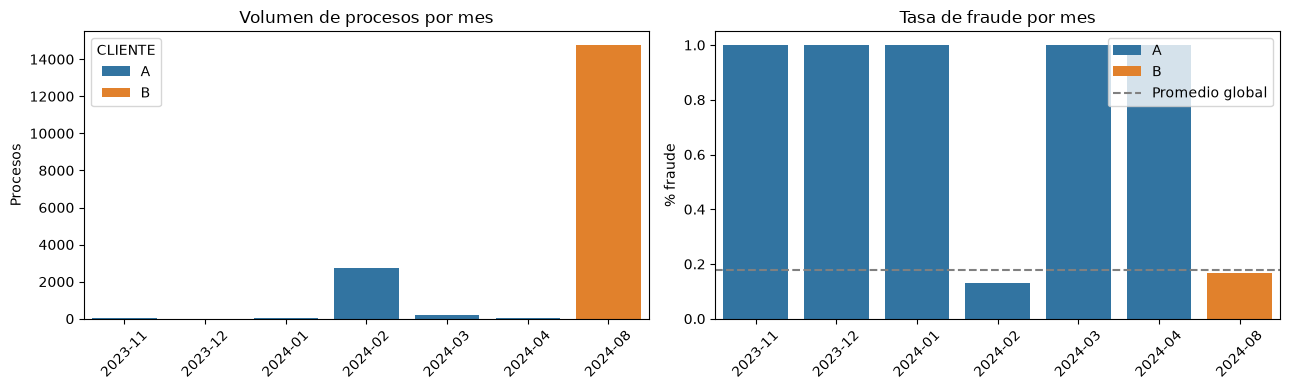

In [13]:
mensual = df.groupby(['CLIENTE', 'MES'])['IS_FRAUD'].agg(['count', 'mean']).reset_index()
mensual['MES'] = mensual['MES'].astype(str)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=mensual, x='MES', y='count', hue='CLIENTE', ax=ax[0])
ax[0].set(title='Volumen de procesos por mes', xlabel='', ylabel='Procesos')
sns.barplot(data=mensual, x='MES', y='mean', hue='CLIENTE', ax=ax[1])
ax[1].axhline(y.mean(), ls='--', c='gray', label='Promedio global')
ax[1].set(title='Tasa de fraude por mes', xlabel='', ylabel='% fraude')
ax[1].legend()
for a in ax:
    a.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

> **HALLAZGO 2. La distribución temporal está sesgada.**
> Los meses con 100 % de fraude (nov 2023 – ene 2024, mar – abr 2024) indican que de esos periodos solo se guardaron los casos de fraude: es sesgo de selección, no tráfico real. Además los clientes no se solapan: A va de nov 2023 a abr 2024 y B es solo agosto 2024. Una partición temporal equivaldría a entrenar con A y probar con B.

Si no se puede partir por tiempo, ¿cómo se parte? Depende de si la etiqueta es por intento o por cuenta.

## 7. ¿La etiqueta es por intento o por cuenta?

In [14]:
intentos = df.groupby('ACCOUNT_ID').size()
intentos.value_counts().head(8)

1     7863
2     3694
3      417
4      130
5       54
6       20
8        7
12       3
Name: count, dtype: int64

In [15]:
etiquetas = df.groupby('ACCOUNT_ID')['IS_FRAUD'].nunique()
multi = intentos[intentos > 1].index

print("Cuentas con varios intentos:", len(multi))
print("De esas, cuentas cuantas tienen etiquetas mezcladas: ",(etiquetas.loc[multi] == 2).sum())

Cuentas con varios intentos: 4343
De esas, cuentas cuantas tienen etiquetas mezcladas:  159


**Conclusión:** de 4.343 cuentas con varios intentos, solo 159 (3,7 %) mezclan fraude y no fraude: la etiqueta es **casi por cuenta**.

Si una cuenta queda repartida entre entrenamiento y prueba, el modelo "reconoce" la cuenta en lugar de aprender patrones de fraude, y las métricas salen infladas. **La partición se hace agrupando por `ACCOUNT_ID`**, estratificada por cliente y etiqueta.

Con la organización de los datos entendida, la siguiente pregunta es qué variables se relacionan con el fraude.

## 8. Señal de cada variable
**Pregunta:** ¿qué tanto separa cada variable el fraude del no fraude?

Para numéricas y booleanas uso el AUC de cada variable sola: 0,5 es azar; lejos de 0,5 en cualquier dirección hay señal (por debajo de 0,5, la relación es inversa).

In [16]:
numericas = ['SUSPECT_SCORE', 'CONFIDENCE_SCORE',
             'VELOCITY_DISTINCT_IP_5M', 'VELOCITY_DISTINCT_IP_1H', 'VELOCITY_DISTINCT_IP_24H',
             'BROWSER_VERSION', 'OS_VERSION', 'LATITUDE', 'LONGITUDE',
             'INCOGNITO', 'PUBLIC_VPN', 'RELAY', 'OS_MISMATCH', 'TIMEZONE_MISMATCH',
             'VISITOR_FOUND', 'VPN_RESULT',
             'DISTRUST', 'Distrust', 'ANOMALY', 'Anomaly', 'LIFETIME', 'Lifetime']

filas = []
for c in numericas:
    s = pd.to_numeric(df[c], errors='coerce')
    ok = s.notna()
    filas.append((c, round(roc_auc_score(y[ok], s[ok]), 3), ok.sum()))

pd.DataFrame(filas, columns=['variable', 'AUC', 'n']).sort_values('AUC')

,variable,AUC,n
20,LIFETIME,0.278,12577
21,Lifetime,0.285,1812
15,VPN_RESULT,0.488,17781
2,VELOCITY_DISTINCT_IP_5M,0.490,17781
8,LONGITUDE,0.491,17781
3,VELOCITY_DISTINCT_IP_1H,0.493,17781
4,VELOCITY_DISTINCT_IP_24H,0.494,17781
10,PUBLIC_VPN,0.496,17781
1,CONFIDENCE_SCORE,0.496,17781
6,OS_VERSION,0.497,17781


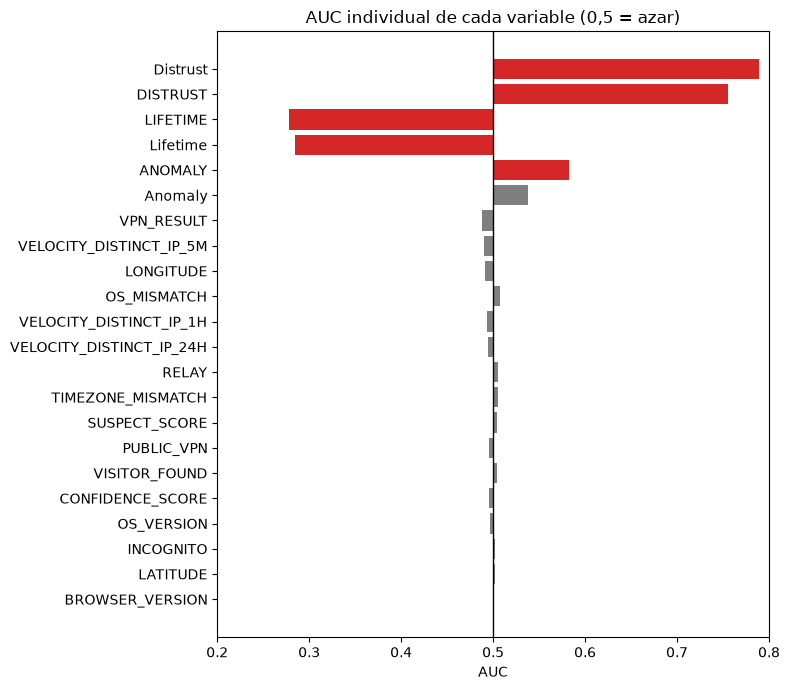

In [17]:
aucs = pd.DataFrame(filas, columns=['variable', 'AUC', 'n'])
aucs['distancia_al_azar'] = (aucs['AUC'] - 0.5).abs()
aucs = aucs.sort_values('distancia_al_azar')

fig, ax = plt.subplots(figsize=(8, 7))
colores = ['tab:red' if d > 0.05 else 'tab:gray' for d in aucs['distancia_al_azar']]
ax.barh(aucs['variable'], aucs['AUC'] - 0.5, left=0.5, color=colores)
ax.axvline(0.5, c='black', lw=1)
ax.set(title='AUC individual de cada variable (0,5 = azar)', xlabel='AUC', xlim=(0.2, 0.8))
plt.tight_layout()
plt.show()

In [18]:
for c in ['BROWSER_NAME', 'OS', 'DEVICE', 'COUNTRY_CODE', 'VPN_CONFIDENCE', 'DOCUMENT_TYPE']:
    print(df.groupby(c, dropna=False)['IS_FRAUD'].agg(['mean', 'count']).round(3), '\n')

               mean  count
BROWSER_NAME              
Chrome        0.174   4323
Edge          0.173   4486
Firefox       0.180   4514
Safari        0.181   4458 

          mean  count
OS                   
Android  0.162   3451
Linux    0.182   3594
Windows  0.173   3546
iOS      0.185   3553
macOS    0.183   3637 

          mean  count
DEVICE               
Desktop  0.181   4464
Mobile   0.176   4494
Other    0.180   4393
Tablet   0.171   4430 

               mean  count
COUNTRY_CODE              
BR            0.182   4393
GB            0.167   4491
JP            0.182   4461
US            0.177   4436 

                 mean  count
VPN_CONFIDENCE              
high            0.177   5927
low             0.181   5846
medium          0.173   6008 

                mean  count
DOCUMENT_TYPE              
foreign-id     0.000     56
national-id    0.182  13515
ppt            0.018   1096
NaN            0.213   3114 



**Observaciones:**
- Casi todo está entre 0,49 y 0,51: scores, velocidades, versiones, coordenadas y todos los booleanos de dispositivo y red.
- Las categóricas están planas: navegador, sistema operativo, dispositivo y país rondan todos el 17–18 % de fraude, cerca del promedio.
- Excepciones: `DISTRUST`/`Distrust` (0,76 y 0,79), `LIFETIME`/`Lifetime` (≈ 0,28, relación inversa fuerte), `ANOMALY` (≈ 0,58) y `DOCUMENT_TYPE` (PPT 1,8 % frente a 18,2 % de la cédula nacional).

Es muy raro que VPN, modo incógnito o velocidad de IPs no tengan **ninguna** relación con el fraude: en la industria están entre las señales más usadas. Antes de concluir que "no sirven", hay que preguntar si estos datos son reales.

## 9. ¿Las variables de dispositivo y red son coherentes?
**a) ¿El código de país coincide con el nombre del país?**

In [19]:
pd.crosstab(df['COUNTRY_CODE'], df['COUNTRY_NAME'])

COUNTRY_NAME,Brazil,Japan,United Kingdom,United States
COUNTRY_CODE,,,,
BR,1059,1095,1103,1136
GB,1134,1119,1079,1159
JP,1127,1097,1105,1132
US,1103,1102,1103,1128


In [20]:
mapa = {'GB': 'United Kingdom', 'JP': 'Japan', 'US': 'United States', 'BR': 'Brazil'}
(df['COUNTRY_CODE'].map(mapa) == df['COUNTRY_NAME']).mean()

np.float64(0.24537427591249086)

La tabla está repartida de forma pareja (≈ 1.100 por celda) y la coincidencia es del 24,5 %: exactamente lo que daría elegir entre 4 países al azar (1/4).

**b) ¿La zona horaria coincide con el país?**

In [21]:
pd.crosstab(df['COUNTRY_CODE'], df['TIMEZONE'])

TIMEZONE,America/Sao_Paulo,Asia/Tokyo,Europe/London
COUNTRY_CODE,,,
BR,1482,1403,1508
GB,1471,1485,1535
JP,1476,1521,1464
US,1486,1498,1452


In [22]:
mapa_tz = {'BR': 'America/Sao_Paulo', 'GB': 'Europe/London', 'JP': 'Asia/Tokyo'}
coincide = df['COUNTRY_CODE'].map(mapa_tz) == df['TIMEZONE']

print('Total:', coincide.mean().round(3))
print('Sin US:', coincide[df['COUNTRY_CODE'] != 'US'].mean().round(3))

Total: 0.255
Sin US: 0.34


Sin contar US (que no tiene zona horaria en los datos), la coincidencia es del 34 %, igual que elegir al azar entre 3 zonas horarias (1/3).

**c) ¿Las velocidades de IP tienen sentido?** Las IPs distintas en 5 minutos no pueden ser más que en 1 hora.

In [23]:
print('5 min > 1 hora:', (df['VELOCITY_DISTINCT_IP_5M'] > df['VELOCITY_DISTINCT_IP_1H']).mean().round(3))
print('1 hora > 24 h :', (df['VELOCITY_DISTINCT_IP_1H'] > df['VELOCITY_DISTINCT_IP_24H']).mean().round(3))

5 min > 1 hora: 0.45
1 hora > 24 h : 0.457


En el 45 % de las filas hay más IPs distintas en 5 minutos que en 1 hora, y en el 46 % más en 1 hora que en 24 horas. Es imposible.

**d) ¿Las fechas de "visto por primera vez" son anteriores a la transacción?**

In [24]:
fsg = pd.to_datetime(df['FIRST_SEEN_GLOBAL'], utc=True, format='ISO8601')
print(fsg.min(), fsg.max())
print('Posterior a DATE:', (fsg > df['DATE']).mean())

2025-05-05 00:00:10.974000+00:00 2025-05-05 23:59:56.974000+00:00
Posterior a DATE: 1.0


Todas caen el 5 de mayo de 2025, después de todas las transacciones (nov 2023 – ago 2024).

**e) ¿La geolocalización es plausible?**

In [25]:
df[['LATITUDE', 'LONGITUDE']].describe()

,LATITUDE,LONGITUDE
count,17781.000000,17781.000000
mean,0.164793,-0.150189
std,52.387133,103.771828
min,-89.995126,-179.988345
25%,-45.158331,-89.697672
50%,-0.111898,-0.808438
75%,46.036340,89.083595
max,89.984135,179.994945


La latitud va de -90 a 90: puntos en todo el planeta, incluidos los polos, aunque solo hay 4 países.

> **HALLAZGO 3. Las variables de dispositivo, red y geografía fueron reemplazadas por valores aleatorios en la anonimización.**
> País, zona horaria y ciudad se combinan al azar; las velocidades de IP son imposibles; las fechas de primer avistamiento son posteriores a las transacciones; la geolocalización cubre todo el planeta. Esto explica el AUC ≈ 0,5 del §8.

## 9.5 ¿El ruido tiene señal combinado?
En el §8 cada columna tenía AUC ≈ 0,5 **por separado**, pero una variable sin señal sola podría tenerla combinada con otras. Para descartarlo, entreno un LightGBM con **todas** las columnas de ruido juntas y lo comparo con:
- **un control negativo**: la misma entrada con la etiqueta barajada al azar ("lo que da el azar puro"), y
- **un control positivo**: 3 señales reales, para mostrar que el método sí detecta señal cuando existe.

Uso validación cruzada de 5 folds agrupada por cuenta (§7).

In [26]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score

SEMILLA = 42
grupos = df['ACCOUNT_ID']

# Columnas sin señal individual (§8) e internamente incoherentes (§9)
ruido = ['COUNTRY_CODE', 'COUNTRY_NAME', 'CITY_NAME', 'POSTAL_CODE', 'LATITUDE', 'LONGITUDE',
         'TIMEZONE', 'TIMEZONE_MISMATCH', 'DEVICE', 'BROWSER_NAME', 'BROWSER_VERSION', 'OS',
         'OS_VERSION', 'OS_MISMATCH', 'INCOGNITO', 'PUBLIC_VPN', 'RELAY', 'VPN_RESULT',
         'VPN_CONFIDENCE', 'VISITOR_FOUND', 'VELOCITY_DISTINCT_IP_5M', 'VELOCITY_DISTINCT_IP_1H',
         'VELOCITY_DISTINCT_IP_24H', 'SUSPECT_SCORE', 'CONFIDENCE_SCORE']

# Control positivo: las tres señales que sí mostraron relación en §8, unificadas como en §5
senales = pd.DataFrame({
    'DISTRUST_U': df['DISTRUST'].fillna(df['Distrust']),
    'ANOMALY_U': df['ANOMALY'].fillna(df['Anomaly']),
    'LIFETIME_U': df['LIFETIME'].fillna(df['Lifetime']),
})


def preparar(X):
    """LightGBM necesita números o categorías."""
    X = X.copy()
    for c in X.columns:
        if X[c].dtype == bool:
            X[c] = X[c].astype(int)
        elif not pd.api.types.is_numeric_dtype(X[c]):
            X[c] = X[c].astype('category')
    return X


def auc_cv(X, objetivo):
    """AUC con validación cruzada de 5 folds agrupada por cuenta."""
    modelo = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, verbose=-1,
                                random_state=SEMILLA)
    cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
    s = cross_val_score(modelo, X, objetivo, cv=cv, groups=grupos, scoring='roc_auc')
    return round(s.mean(), 3), round(s.std(), 3)


X_ruido = preparar(df[ruido])
y_azar = pd.Series(np.random.default_rng(SEMILLA).permutation(y.values), index=y.index)

pd.DataFrame(
    [('Columnas de ruido', len(ruido), *auc_cv(X_ruido, y)),
     ('Control negativo: ruido con etiqueta barajada', len(ruido), *auc_cv(X_ruido, y_azar)),
     ('Control positivo: DISTRUST, ANOMALY, LIFETIME', senales.shape[1], *auc_cv(senales, y))],
    columns=['Experimento', 'Variables', 'AUC media', 'AUC desv.'],
)

,Experimento,Variables,AUC media,AUC desv.
0,Columnas de ruido,25,0.490,0.010
1,Control negativo: ruido con etiqueta barajada,25,0.489,0.006
2,"Control positivo: DISTRUST, ANOMALY, LIFETIME",3,0.762,0.017


**Conclusión:** el modelo con las 25 columnas de ruido combinadas obtiene AUC ≈ 0,49, indistinguible del control negativo con la etiqueta barajada. Con el mismo método, 3 señales reales alcanzan ≈ 0,76: el método sí detecta señal cuando existe.

Las columnas de dispositivo, red y geografía no aportan información, ni solas ni combinadas. **Se excluyen.** Con datos reales sin anonimizar serían de las primeras a evaluar.

## 10. Fuga de información
**Pregunta:** ¿`STATUS` y `DECLINED_REASON` existen antes de decidir, o son el resultado del proceso?

In [27]:
pd.crosstab(df['STATUS'], df['IS_FRAUD'], normalize='index').round(3)

IS_FRAUD,False,True
STATUS,,
failure,0.713,0.287
success,0.890,0.110


In [28]:
motivos = df.groupby('DECLINED_REASON')['IS_FRAUD'].agg(['mean', 'count'])
motivos[motivos['count'] >= 20].sort_values('mean', ascending=False).round(3)

,mean,count
DECLINED_REASON,,
no_document_media_uploaded,1.000,30
not_used,1.000,43
portrait_photo_is_fake,0.981,52
fraudster_face_match_in_client_collection,0.926,27
possible_fraud,0.829,117
blurry_image,0.630,27
image_face_validation_not_passed,0.572,512
document_is_a_photo_of_photo,0.552,270
document_is_a_photocopy,0.425,873


**Conclusión:** `failure` tiene 28,7 % de fraude frente a 11,0 % en `success`, y varios motivos casi son la etiqueta: `no_document_media_uploaded` (100 %), `portrait_photo_is_fake` (98 %), `fraudster_face_match_in_client_collection` (93 %), `possible_fraud` (83 %).

Son el **resultado** de la verificación de documento y rostro. Si el modelo decide antes de esa verificación, usarlas es fuga de información. El EDA no puede decidir esto (es un supuesto de negocio, S3), pero sí muestra cuánto pesan, lo que justifica comparar un modelo con ellas y otro sin ellas.

Descartado el ruido y aislada la fuga: ¿con qué señal real contamos?

## 11. Dónde sí hay señal
**a) `DISTRUST` unificada**

In [29]:
df['DISTRUST_U'] = df['DISTRUST'].fillna(df['Distrust'])
df['ANOMALY_U'] = df['ANOMALY'].fillna(df['Anomaly'])
df['LIFETIME_U'] = df['LIFETIME'].fillna(df['Lifetime'])

tramos = pd.cut(df['DISTRUST_U'], [-0.01, 0, 0.25, 0.5, 0.75, 0.9, 1.0])
df.groupby(tramos)['IS_FRAUD'].agg(['mean', 'count']).round(3)

,mean,count
DISTRUST_U,,
"(-0.01, 0.0]",0.066,8166
"(0.0, 0.25]",0.106,1563
"(0.25, 0.5]",0.131,1544
"(0.5, 0.75]",0.178,1528
"(0.75, 0.9]",0.337,1326
"(0.9, 1.0]",0.460,2516


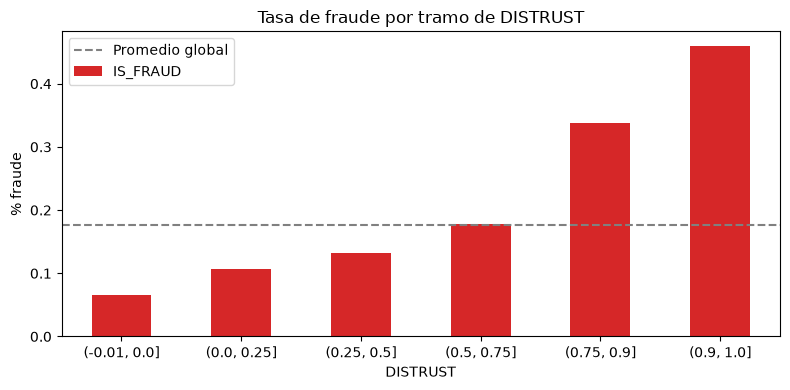

In [30]:
por_tramo = df.groupby(tramos, observed=True)['IS_FRAUD'].mean()

fig, ax = plt.subplots(figsize=(8, 4))
por_tramo.plot.bar(ax=ax, color='tab:red')
ax.axhline(y.mean(), ls='--', c='gray', label='Promedio global')
ax.set(title='Tasa de fraude por tramo de DISTRUST', xlabel='DISTRUST', ylabel='% fraude')
ax.tick_params(axis='x', rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

El fraude sube de forma casi monótona con `DISTRUST`: ≈ 7 % con valor 0 y cerca del 45 % en la parte alta.

**b) Historial de la cuenta**

In [31]:
df = df.sort_values('DATE')
df['INTENTOS_PREVIOS'] = df.groupby('ACCOUNT_ID').cumcount()
df.groupby(df['INTENTOS_PREVIOS'].clip(upper=3))['IS_FRAUD'].agg(['mean', 'count']).round(3)

,mean,count
INTENTOS_PREVIOS,,
0,0.145,12206
1,0.206,4343
2,0.247,649
3,0.556,583


14,5 % de fraude en el primer intento → 20,6 % → 24,7 % → 55,6 % desde el cuarto.

**c) Identidad compartida entre cuentas**

In [32]:
for col in ['DOCUMENT_NUMBER', 'EMAIL', 'PHONE_NUMBER']:
    cuentas_por_valor = df.groupby(col)['ACCOUNT_ID'].nunique()
    compartido = df[col].map(cuentas_por_valor) > 1
    print(col)
    print(df.groupby(compartido)['IS_FRAUD'].agg(['mean', 'count']).round(3), '\n')

DOCUMENT_NUMBER
                  mean  count
DOCUMENT_NUMBER              
False            0.168  17231
True             0.449    550 

EMAIL
        mean  count
EMAIL              
False  0.169  17350
True   0.480    431 

PHONE_NUMBER
               mean  count
PHONE_NUMBER              
False         0.176  17745
True          0.694     36 



Un documento usado por más de una cuenta tiene 44,9 % de fraude; un email, 48 %; un teléfono, 69,4 % (frente al 17,7 % base).

⚠️ Aquí las variables se calcularon con todo el dataset, incluido el futuro. En el pipeline se calculan solo con información anterior a cada fila, y un test lo verifica (`tests/test_point_in_time.py`).

**d) Faltantes como señal**

In [33]:
for col in ['DOCUMENT_TYPE', 'DOCUMENT_NUMBER', 'LIFETIME_U']:
    print(col, df.groupby(df[col].isna())['IS_FRAUD'].mean().round(3).to_dict())

DOCUMENT_TYPE {False: 0.169, True: 0.213}
DOCUMENT_NUMBER {False: 0.182, True: 0.052}
LIFETIME_U {False: 0.159, True: 0.254}


Que falte un dato no es neutro: sin `LIFETIME` el fraude sube a 25,4 % (frente a 15,9 %), y sin `DOCUMENT_TYPE` a 21,3 % (aunque esto coincide con el cliente A, que no tiene esa columna). En cambio, sin `DOCUMENT_NUMBER` baja a 5,2 %. En los dos sentidos, el faltante es información: se agregan indicadores de faltante y el modelo aprende la dirección.

## 12. Conclusiones y decisiones para el pipeline

| Hallazgo | Sección | Decisión |
|---|---|---|
| Dos esquemas según el cliente | §5 | Unificar `DISTRUST`, `ANOMALY` y `LIFETIME`; indicadores de faltante; `CLIENTE` para estratificar y monitorear (como variable no aporta, ver Fase 3) |
| Meses con 100 % de fraude; clientes sin solaparse | §6 | Sin partición temporal; las filas sesgadas se excluyen de entrenamiento y evaluación (`biased_periods`) |
| Etiqueta casi por cuenta | §7 | Partición agrupada por `ACCOUNT_ID`, estratificada por cliente y etiqueta |
| Dispositivo, red y geografía aleatorizados | §8, §9, §9.5 | Excluir |
| `STATUS` y `DECLINED_REASON` son resultado | §10 | Modelo principal sin ellos; variante con ellos para comparar |
| Señal en `DISTRUST`, antigüedad, historial e identidad compartida | §11 | Variables principales, calculadas solo con el pasado |
| Identificadores, constantes, `PROCESS_DATE` | §4, §5 | Excluir |

### Decisiones trasladadas al pipeline
Las conclusiones quedan codificadas en `config.yaml`:
- `unify`, `clients` ← §5
- `biased_periods` ← §6
- `excluded.ruido_sintetico` ← §8, §9, §9.5
- `excluded.identificadores`, `constantes`, `redundantes` ← §4, §5
- `features.leakage` ← §10

Los supuestos derivados están en `docs/supuestos.md`.